# W01 Mon — Setup and Orientation
## IIT414W · Unit I · Week 1 · Mon March 2, 2026

**Learning goals for this session:**
- Verify Python, conda/pip, Jupyter, and Git are correctly installed.
- Clone the course repo and run a reproducibility check.
- Understand the vibe-coder vs. agentic-engineer spectrum.
- Make a F1 winner prediction (intuition-based, no model) and document it.

**Before you start:** Confirm your environment is created from `environment.yml` or `requirements.txt` and that Git is available in your terminal.



In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')


Python  : 3.10.20
NumPy   : 1.26.4
Seed    : 414


In [2]:
# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

All required packages already installed ✓
fastf1  : 3.3.9
pandas  : 2.2.3


## 1. Environment Verification

**The idea.** We verify that the full local toolchain works before any analysis.

**In F1 terms.** A team validates telemetry feeds before strategy simulation.

> **Why it matters:** Setup problems masquerade as modeling mistakes if not checked first.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > How will we prove this machine can reproduce course notebooks from scratch?

2. **What does success look like? How will we know if the result is good?**
   > The notebook runs start-to-finish without errors, reproducing key figures,tables and using the expected package versions.

3. **What could go wrong? Name one failure mode.**
   > Missing or incompatible packages causing runtime errors or different outputs compared to the course reference.


In [3]:
required = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'fastf1']
rows = []
for pkg in required:
    mod = importlib.import_module(pkg)
    rows.append((pkg, getattr(mod, '__version__', 'n/a')))

print(pd.DataFrame(rows, columns=['package', 'version']).to_string(index=False))
print(f'Working directory: {os.getcwd()}')

# FastF1 cache — auto-create if missing
cache_path = os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'fastf1_cache')
cache_path = os.path.abspath(cache_path)
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)
print(f'FastF1 cache enabled: {cache_path}')

print(subprocess.run(['git', '--version'], capture_output=True, text=True, check=False).stdout.strip())
log = subprocess.run(['git', 'log', '--oneline', '-5'], capture_output=True, text=True, check=False)
print('Recent commits:')
print(log.stdout.strip() if log.returncode == 0 else 'No commit history available in this folder.')

   package version
     numpy  1.26.4
    pandas   2.2.3
   sklearn   1.4.2
matplotlib   3.8.4
   seaborn  0.13.2
    fastf1   3.3.9
Working directory: c:\Users\benja\OneDrive\Documents\GitHub\iit414w-lab00-Elm3rFgr0a
FastF1 cache enabled: c:\Users\benja\OneDrive\Documents\data\fastf1_cache
git version 2.53.0.windows.1
Recent commits:
6b63595 Primer commit


In [4]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Run one additional system check and explain why it supports reproducibility.
# Expected output: A short printout plus one risk note.
# Hint: You can check `sys.executable`, platform info, or free disk space.

import os, sys, platform, shutil

# Report interpreter and platform — important for reproducing environments
print('Python executable :', sys.executable)
print('Python version    :', platform.python_version(), f'({platform.system()} {platform.release()})')

# Check available disk space on the current filesystem (GB)
total, used, free = shutil.disk_usage(os.getcwd())
gb = lambda b: b / 1024**3
print(f'Disk free         : {gb(free):.1f} GB of {gb(total):.1f} GB')

# One-line interpretation for reproducibility
print()
print('Risk note: If "sys.executable" points to a different interpreter (e.g., system Python vs. virtualenv),')
print('           package versions and installed libraries may differ; low disk space can break caching or downloads.')


Python executable : c:\Users\benja\miniconda3\envs\iit414w\python.exe
Python version    : 3.10.20 (Windows 10)
Disk free         : 102.5 GB of 179.1 GB

Risk note: If "sys.executable" points to a different interpreter (e.g., system Python vs. virtualenv),
           package versions and installed libraries may differ; low disk space can break caching or downloads.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**
   > I learned that small environment differences can prevent exact notebook reproduction.

2. **Where could this technique fail or mislead you?**
   > It can miss subtle dependency or data issues and doesn't guarantee identical random seeds across libraries, so outputs may still diverge.

3. **How would you explain this to a non-technical teammate?**
   > It's a quick health check that confirms we're using the same Python, packages, and enough disk space so the notebook runs the same way on another machine.


## 2. The Vibe Coder vs. Agentic Engineer

**The idea.** Agentic workflows require explicit decisions, checks, and evidence.

**In F1 terms.** Race engineers never trust a single number without validating context and assumptions.

> **Why it matters:** Decision quality, not code volume, is what we grade in this course.


### Spectrum Examples — Code Snippets

**Example 1 — AI suggests a train/test split:**

Vibe Coder:
```python
# AI says: just use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# "Looks fine!" → ships it
```

Agentic Engineer:
```python
# Wait — is this temporal data? Random split could leak future info.
# Check: are there date columns? Is order meaningful?
print(df['year'].unique())  # 2019, 2020, 2021, 2022, 2023
# → Random split mixes years. Must split by time, not randomly.
```

**Example 2 — Model accuracy is 92%:**

Vibe Coder:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
# "Great score!" → done
```

Agentic Engineer:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
print(f"Majority baseline: {y_test.mean():.2f}")          # 0.90
# → Only 2% above always-predicting-majority. Basically useless.
```

**Example 3 — AI generates a feature engineering function:**

Vibe Coder:
```python
# Copies AI output directly into pipeline → no validation
def engineer_features(df):
    df['avg_position'] = df.groupby('driver')['position'].transform('mean')
    return df  # Uses future races to compute mean → leakage!
```

Agentic Engineer:
```python
# Before using: Does this use future information?
# 'mean' over ALL rows includes future races → target leakage!
# Fix: use expanding mean up to current race only
df['avg_position'] = df.groupby('driver')['position'].transform(
    lambda x: x.shift(1).expanding().mean()
)
```

| Scenario | Vibe Coder | Agentic Engineer |
|---|---|---|
| AI suggests code | Copies and runs | Tests assumptions and edge cases |
| Plot looks clean | Accepts narrative | Verifies labels, units, and sampling |
| Metric improves | Declares success | Checks leakage and baseline comparisons |

### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which one of your current coding habits is most likely to create silent errors?

2. **What does success look like? How will we know if the result is good?**
   > Silent errors are reduced. Errors are handled explicitly, logged, or cause test failures before reaching production.

3. **What could go wrong? Name one failure mode.**
   > Tightening error handling could reveal many hidden issues at once, causing crashes until proper fixes or fallbacks are implemented.


In [5]:
self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [None, None, None, None, None],
    }
)
print(self_check.to_string(index=False))


                                   statement score_1_to_5
      I define success metrics before coding         None
  I verify train/val/test leakage explicitly         None
   I validate AI-generated code before reuse         None
                  I document failed attempts         None
I justify every modeling decision in writing         None


In [ ]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the checklist and write one concrete action to improve your lowest-scoring item.
# Expected output: A completed table and one action sentence.
# Hint: Honest scoring is more useful than optimistic scoring.

# Fill the checklist with honest scores (1=low, 5=high)
# Be realistic — the lowest item will get a concrete action.
scores = [3, 2, 3, 1, 3] # Scores
self_check['score_1_to_5'] = scores
print(self_check.to_string(index=False))

# Identify lowest-scoring item(s)
min_score = min(scores)
lowest = self_check[self_check['score_1_to_5'] == min_score]
print()
print('Lowest scoring item(s):')
for row in lowest.itertuples(index=False):
    print(f'- {row.statement} (score={row.score_1_to_5})')

# One concrete action to improve the lowest-scoring habit (single sentence)
action = ('I will start a "reproducibility journal" where I document all my experiments, including failed attempts, to ensure I learn from them and maintain a clear record of my modeling decisions.')
print()
print('Action:', action)


                                   statement  score_1_to_5
      I define success metrics before coding             3
  I verify train/val/test leakage explicitly             2
   I validate AI-generated code before reuse             3
                  I document failed attempts             1
I justify every modeling decision in writing             3

Lowest scoring item(s):
- I document failed attempts (score=1)

Action: I will start a "reproducibility journal" where I document all my experiments, including failed attempts, to ensure I learn from them and maintain a clear record of my modeling decisions.


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

> Even when you set the same random seed, results can still differ: different library versions or Python builds may implement algorithms slightly differently, so a seed alone doesn’t guarantee identical outputs across machines.

2. **Where could this technique fail or mislead you?**

> Passing environment checks can give a false sense of reproducibility while hiding subtle issues like data leakage or different numeric precisions across library versions that change final results.

3. **How would you explain this to a non-technical teammate?**

> It’s like following the same recipe but using different ovens and measuring cups: it looks the same on paper, but small tool differences can change the final dish, so we verify tools, versions, and steps, not just the ingredients.


## 3. Your First F1 Data Pull

**The idea.** We pull real FastF1 data and inspect lap-level structure before modeling.

**In F1 terms.** This is like opening timing screens before deciding race strategy.

> **Why it matters:** Early data literacy prevents poor feature assumptions later.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What pattern do you expect to see in top-driver qualifying lap distributions?

2. **What does success look like? How will we know if the result is good?**
   > The session data loads cleanly, lap times are parsed into numeric seconds, and summary stats or plots let us identify patterns

3. **What could go wrong? Name one failure mode.**
   > The data fails to load or laps are missing, preventing valid comparisons.


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.3.9]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Cannot calculate qualifying results: missing information about deleted laps. Make sure that race control messages are being loaded.
logger      WARNING 	Failed to calculate quali results from lap times!
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '44', '1', '55', '63', '27', '20', '16', '11

First 5 laps for VER:
Driver  LapNumber                LapTime Compound
   VER        2.0 0 days 00:01:23.516000     SOFT
   VER        3.0 0 days 00:01:56.133000     SOFT
   VER        5.0 0 days 00:01:23.612000     SOFT
   VER        6.0 0 days 00:01:35.987000     SOFT
   VER        8.0 0 days 00:01:22.998000     SOFT


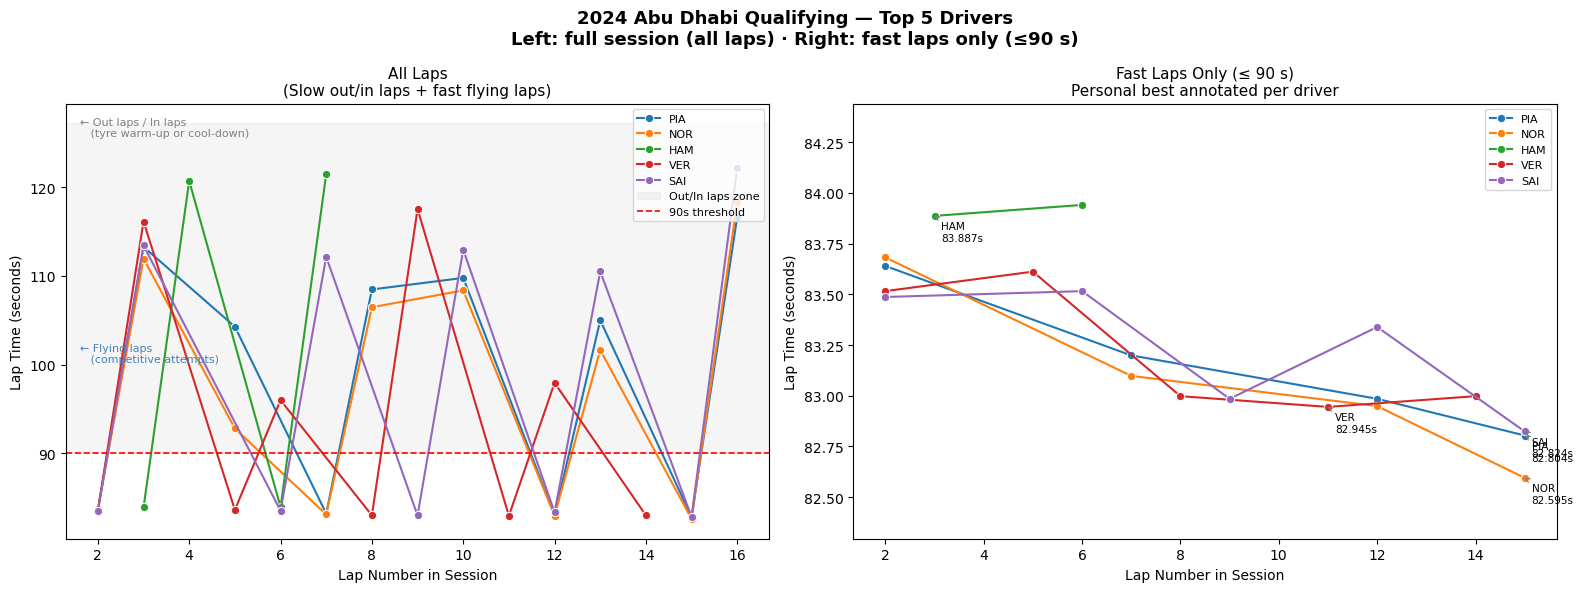


── Best Qualifying Lap per Driver (Top 5) ──
Driver  BestLapSec  GapToPole
   NOR      82.595      0.000
   PIA      82.804      0.209
   SAI      82.824      0.229
   VER      82.945      0.350
   HAM      83.887      1.292

💡 GapToPole: how many seconds behind the fastest qualifier each driver was.


In [7]:
# ── Load a Formula 1 Session ──────────────────────────────────────────────────
# fastf1.get_session() identifies a session by: year, event name (or round number), and session type.
# Session types: 'FP1', 'FP2', 'FP3' (Free Practice), 'Q' (Qualifying), 'R' (Race), 'S' (Sprint)
# 'Abu Dhabi' is the final race of the 2024 F1 season (Round 24).
session = fastf1.get_session(2024, 'Abu Dhabi', 'Q')

# session.load() fetches data from the FastF1 cache (or downloads it if not cached).
# We only need lap data here, so we disable the heavier telemetry/weather/messages
# to speed up loading. Set any of these to True if you need that data later.
#   laps=True      → lap-by-lap timing data (required for this analysis)
#   telemetry=False → car sensor data (speed, throttle, brake, gear) — not needed here
#   weather=False   → track temperature, wind, rain data — not needed here
#   messages=False  → race control messages (flags, penalties) — not needed here
session.load(laps=True, telemetry=False, weather=False, messages=False)

# ── Inspect VER (Max Verstappen) Lap Data ─────────────────────────────────────
# session.laps returns a special FastF1 DataFrame (Laps object) with all drivers.
# pick_drivers('VER') filters by driver abbreviation (3-letter code used in F1 broadcasts).
# Common abbreviations: NOR=Norris, VER=Verstappen, HAM=Hamilton, LEC=Leclerc, etc.
# LapTime is stored as a pandas Timedelta (days + HH:MM:SS.microseconds), not a float.
# dropna() removes laps where any selected column has missing data (e.g. aborted laps).
ver_laps = session.laps.pick_drivers('VER')[['Driver', 'LapNumber', 'LapTime', 'Compound']].dropna().head(5)
print('First 5 laps for VER:')
print(ver_laps.to_string(index=False))

# ── Get the Top 5 Qualifiers from Official Results ────────────────────────────
# session.results is a DataFrame with one row per driver, containing official timing.
# In qualifying, Position=1 is pole position (fastest overall Q3 time).
# We copy it to avoid accidentally modifying the original session data.
res = session.results.copy()

# Position can sometimes be stored as a string or mixed type — coerce to numeric.
# errors='coerce' turns any non-numeric value into NaN instead of raising an error.
res['Position'] = pd.to_numeric(res['Position'], errors='coerce')

# nsmallest(5, 'Position') picks the 5 rows with the lowest (best) position numbers.
# 'Abbreviation' gives us the 3-letter driver codes we need for lap filtering.
top5 = res.nsmallest(5, 'Position')['Abbreviation'].tolist()

# ── Build Plotting DataFrame for Top 5 Drivers ───────────────────────────────
# pick_drivers() also accepts a list of abbreviations — it returns all laps for those drivers.
# We keep only the columns we need for plotting: driver name, lap number, and lap time.
# .copy() ensures we work on a fresh DataFrame and not a view (avoids SettingWithCopyWarning).
plot_df = session.laps.pick_drivers(top5)[['Driver', 'LapNumber', 'LapTime']].dropna().copy()

# Convert Timedelta → float (seconds) for easy plotting on a numeric Y axis.
# dt.total_seconds() works on Timedelta columns; e.g. 0 days 00:01:22.595 → 82.595
plot_df['LapTimeSec'] = plot_df['LapTime'].dt.total_seconds()

# ── Separate fast laps from slow laps for cleaner visualization ───────────────
# In qualifying, drivers do:
#   - OUT LAPS  : slow laps to warm up tyres before a fast attempt  (> ~90s here)
#   - FLYING LAPS: the actual timed competitive laps               (<= ~90s here)
#   - IN LAPS   : slow laps returning to the pit box               (> ~90s here)
# We use 90 seconds as a threshold — anything faster is likely a competitive lap.
# Abu Dhabi circuit lap record is ~82s, so 90s gives us a comfortable margin.
# NOTE: This threshold is circuit-specific. For Monaco (~74s lap record) you'd use ~85s;
#       for Monza (~80s) you might use ~88s. Always check before applying.
FAST_LAP_THRESHOLD = 90  # seconds — adjust if session is at a shorter/longer circuit

fast_laps = plot_df[plot_df['LapTimeSec'] <= FAST_LAP_THRESHOLD]
slow_laps = plot_df[plot_df['LapTimeSec'] > FAST_LAP_THRESHOLD]

# ── Plot: Two panels side by side ─────────────────────────────────────────────
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of Axes (subplots).
# figsize=(16, 6) sets the figure width=16 inches, height=6 inches.
# axes[0] = left panel, axes[1] = right panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    '2024 Abu Dhabi Qualifying — Top 5 Drivers\n'
    'Left: full session (all laps) · Right: fast laps only (≤90 s)',
    fontsize=13, fontweight='bold'
)

# ── LEFT PANEL: All laps — shows the full qualifying rhythm ───────────────────
# This panel helps students understand the structure of a qualifying session:
# Q1 (all 20 cars) → Q2 (top 15) → Q3 (top 10), each separated by slow in/out laps.
ax = axes[0]

# sns.lineplot with hue='Driver' automatically assigns a different color per driver
# and draws a line connecting their laps in order. marker='o' adds a dot at each lap.
sns.lineplot(data=plot_df, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# axhspan shades a horizontal band between two Y values across the full X range.
# This visually marks the "slow lap" region (out laps and in laps).
# alpha=0.08 makes the shading very transparent so lines remain readable.
ax.axhspan(FAST_LAP_THRESHOLD, plot_df['LapTimeSec'].max() + 5,
           alpha=0.08, color='gray', label='Out/In laps zone')

# axhline draws a horizontal reference line at y=FAST_LAP_THRESHOLD.
# linestyle='--' = dashed line; this is the boundary between slow and fast laps.
ax.axhline(FAST_LAP_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'{FAST_LAP_THRESHOLD}s threshold')

ax.set_title('All Laps\n(Slow out/in laps + fast flying laps)', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# ax.text with transform=ax.transAxes uses Axes-relative coordinates:
# (0, 0) = bottom-left corner, (1, 1) = top-right corner of the plot area.
# This keeps the annotation in the same relative position regardless of data range.
ax.text(0.02, 0.97, '← Out laps / In laps\n   (tyre warm-up or cool-down)',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')
ax.text(0.02, 0.45, '← Flying laps\n   (competitive attempts)',
        transform=ax.transAxes, fontsize=8, va='top', color='steelblue')

# ── RIGHT PANEL: Fast laps only — reveals true pace comparison ────────────────
# Removing the out/in laps compresses the Y axis, making small differences
# between drivers (often < 0.5s in qualifying) clearly visible.
ax = axes[1]
sns.lineplot(data=fast_laps, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# Annotate the personal best lap for each driver.
# idxmin() returns the index label of the minimum value in the Series.
# ax.annotate() places a text label with an arrow pointing to the data point.
for driver in top5:
    driver_fast = fast_laps[fast_laps['Driver'] == driver]
    if driver_fast.empty:
        continue
    best_row = driver_fast.loc[driver_fast['LapTimeSec'].idxmin()]
    ax.annotate(
        f"{driver}\n{best_row['LapTimeSec']:.3f}s",  # .3f = 3 decimal places (millisecond precision)
        xy=(best_row['LapNumber'], best_row['LapTimeSec']),  # arrow tip: the actual data point
        xytext=(5, -18), textcoords='offset points',         # label offset in pixels from the tip
        fontsize=7.5, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title('Fast Laps Only (≤ 90 s)\nPersonal best annotated per driver', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# Tighten y-axis so small differences between drivers are visible.
# Without this, matplotlib auto-scales to include 0 on the Y axis,
# making a 0.3s gap between pole and P5 almost invisible.
y_min = fast_laps['LapTimeSec'].min()
y_max = fast_laps['LapTimeSec'].max()
ax.set_ylim(y_min - 0.3, y_max + 0.5)  # small padding around the actual data range

# tight_layout() automatically adjusts subplot spacing to prevent label overlap.
plt.tight_layout()
plt.show()

# ── Summary table: Best lap per driver ────────────────────────────────────────
# This table makes it easy to compare pole-lap pace without reading from the chart.
print('\n── Best Qualifying Lap per Driver (Top 5) ──')
best_laps = (
    fast_laps.groupby('Driver')['LapTimeSec']
    .min()                                          # best (minimum) lap time per driver
    .reset_index()                                  # turn the groupby result back into a flat DataFrame
    .rename(columns={'LapTimeSec': 'BestLapSec'})
    .sort_values('BestLapSec')                      # sort fastest → slowest (pole position first)
)
# GapToPole: difference between each driver's best lap and the pole-sitter's best lap.
# iloc[0] is the pole-sitter after sort_values, so subtracting gives 0.000 for pole.
best_laps['GapToPole'] = (best_laps['BestLapSec'] - best_laps['BestLapSec'].iloc[0]).round(3)
print(best_laps.to_string(index=False))
print('\n💡 GapToPole: how many seconds behind the fastest qualifier each driver was.')


In [8]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Compare one additional driver against VER and summarize variance differences.
# Expected output: A table and one interpretation sentence.
# Hint: Use standard deviation of lap times in seconds.

# Choose a driver to compare with VER. Prefer HAM if present, else pick any other top driver.
drivers = fast_laps['Driver'].unique().tolist()
compare_driver = 'HAM' if 'HAM' in drivers else next((d for d in drivers if d != 'VER'), None)

if compare_driver is None:
    print('No other driver data available to compare with VER.')
else:
    stats = []
    for drv in ['VER', compare_driver]:
        times = fast_laps[fast_laps['Driver'] == drv]['LapTimeSec']
        stats.append({'Driver': drv, 'count': int(times.count()), 'std_sec': float(times.std()) if not times.empty else float('nan')})

    stats_df = pd.DataFrame(stats)
    print(stats_df.to_string(index=False))

    ver_std = stats_df.loc[stats_df['Driver'] == 'VER', 'std_sec'].iloc[0]
    cmp_std = stats_df.loc[stats_df['Driver'] == compare_driver, 'std_sec'].iloc[0]

    if pd.isna(ver_std) or pd.isna(cmp_std):
        interp = 'Insufficient lap data to compute variance for one or both drivers.'
    elif ver_std < cmp_std:
        interp = f'VER is more consistent than {compare_driver} (std {ver_std:.3f}s vs {cmp_std:.3f}s).'
    elif ver_std > cmp_std:
        interp = f'VER is less consistent than {compare_driver} (std {ver_std:.3f}s vs {cmp_std:.3f}s).'
    else:
        interp = f'VER and {compare_driver} have similar variance (std {ver_std:.3f}s).'

    print()
    print('Interpretation:', interp)


Driver  count  std_sec
   VER      5 0.322211
   HAM      2 0.038184

Interpretation: VER is less consistent than HAM (std 0.322s vs 0.038s).


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

> Pulling a real qualifying session with fastf1.get_session() is fast and gives rich lap-level detail.

2. **Where could this technique fail or mislead you?**

> Cache or network issues can make the session incomplete, so apparent gaps or inconsistencies may be data problems rather than driver performance.

3. **How would you explain this to a non-technical teammate?**

> We downloaded official lap timing for the session and cleaned it so we can compare drivers like stopwatch readings per lap.


## 4. Prediction Card Activity

**The idea.** We capture a structured forecast before formal modeling begins.

**In F1 terms.** Teams commit assumptions before race outcomes are known, then revisit them.

> **Why it matters:** Documented assumptions reduce hindsight bias and improve learning loops.


### Prediction Card (fill this markdown cell)

1. **Who will win the 2025 Drivers' Championship?**

> I think Max Verstappen will win in 2025.

2. **What data would you use to support that prediction?**

> Qualifying and race lap times, grid positions, sector times and top speeds.

3. **What could go wrong with your prediction?**

> Unexpected events like injuries, penalties, extreme weather, etc.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What assumptions are you making about the 2025 championship winner right now?

2. **What does success look like? How will we know if the result is good?**
   > By mid-season they have a clear points lead from frequent podiums/wins and visible performance gains after upgrades.

3. **What could go wrong? Name one failure mode.**
   > A string of reliability DNFs or a rival’s superior upgrade package derails the campaign.


In [9]:
prediction_card_template = {
    'predicted_2025_champion': '[fill in]',
    'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'],
    'failure_modes': ['[risk 1]', '[risk 2]'],
}
print(prediction_card_template)


{'predicted_2025_champion': '[fill in]', 'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'], 'failure_modes': ['[risk 1]', '[risk 2]']}


In [ ]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the prediction card in this notebook and keep it for Week 6 revisit.
# Expected output: A completed dictionary with explicit assumptions.
# Hint: Be specific about what could invalidate your prediction.

# Fill the prediction card with concise, testable items
prediction_card = {
    'predicted_2025_champion': 'McLaren',
    'evidence_plan': [
        'lap_times (mean + variance) across sessions',
        'qualifying grid positions and Q3 frequency',
        'sector/top-speed and stint degradation curves',
        'pit-stop time distribution and reliability/DNF history',
    ],
    'assumptions': [
        'team delivers a step improvement early season',
        'both drivers score points consistently',
        'no major rule changes that favour rivals',
    ],
    'failure_modes': [
        'sustained reliability issues or multiple DNFs',
        'rival teams introduce superior upgrade packages',
        'key driver injury, penalties, or unexpected rule changes',
    ],
}
print(prediction_card)


{'predicted_2025_champion': 'McLaren', 'evidence_plan': ['lap_times (mean + variance) across sessions', 'qualifying grid positions and Q3 frequency', 'sector/top-speed and stint degradation curves', 'pit-stop time distribution and reliability/DNF history'], 'assumptions': ['team delivers a step improvement early season', 'both drivers score points consistently', 'no major rule changes that favour rivals'], 'failure_modes': ['sustained reliability issues or multiple DNFs', 'rival teams introduce superior upgrade packages', 'key driver injury, penalties, or unexpected rule changes']}


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**
> I was surprised that turning a hunch into a prediction forces you to be specific. Naming the metrics makes the forecast testable and useful, not just an opinion.

2. **Where could this technique fail or mislead you?**
> It can be overturned by sudden reliability issues or a rival’s better upgrade, and you can also fall prey to confirmation bias by over-interpreting early positive signals

3. **How would you explain this to a non-technical teammate?**
> It’s like betting on a team: I picked McLaren, but we’ll check those exact metrics each week so we know if the bet was justified.


## 5. What Is Machine Learning? (Conceptual Anchor)

**The idea.** ML can be explained at intuitive, technical, and formal levels.

**In F1 terms.** A model is like a pit strategy simulator: useful under known conditions, fragile under shifts.

> **Why it matters:** Clear conceptual framing prevents wrong targets and wrong metrics.


### ML Taxonomy in F1

- **Supervised:** Predict Top-10 finish from pre-race features.
- **Unsupervised:** Cluster circuits by pace profile.
- **Reinforcement Learning:** Optimize pit timing via simulated reward.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which ML paradigm best matches each F1 task: winner prediction, circuit clustering, pit strategy optimization?

2. **What does success look like? How will we know if the result is good?**
   > The predictions produce calibrated scores that perform better than simple baselines and are useful for decision making. The clusters should form groups that make sense with known circuit types and also help improve downstream models.

3. **What could go wrong? Name one failure mode.**
   > The model is trained on past or simulated data, so if race conditions or rules change, its predictions might not match what actually happens in new races.


In [11]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=6, n_informative=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'Synthetic supervised demo accuracy: {accuracy_score(y_test, pred):.3f}')


Synthetic supervised demo accuracy: 0.960


In [12]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Create a 3-row table: supervised, unsupervised, reinforcement learning with one F1 use case each.
# Expected output: A concise paradigm-to-use-case table.
# Hint: Include one risk if each paradigm is misapplied.

ml_table = pd.DataFrame([
    {
        'Paradigm': 'Supervised',
        'Use Case': 'Winner prediction (classification/regression)',
        'Risk If Misapplied': 'Overfitting to past seasons; poor generalization to new conditions',
    },
    {
        'Paradigm': 'Unsupervised',
        'Use Case': 'Circuit clustering by pace/profile (feature discovery)',
        'Risk If Misapplied': 'Clusters that do not reflect actionable circuit differences, misleading downstream models',
    },
    {
        'Paradigm': 'Reinforcement',
        'Use Case': 'Pit strategy optimization via simulation-based policy learning',
        'Risk If Misapplied': 'Simulation gap: learned policy fails on real races due to unmodeled dynamics',
    },
])
print(ml_table.to_string(index=False))


     Paradigm                                                       Use Case                                                                        Risk If Misapplied
   Supervised                  Winner prediction (classification/regression)                        Overfitting to past seasons; poor generalization to new conditions
 Unsupervised         Circuit clustering by pace/profile (feature discovery) Clusters that do not reflect actionable circuit differences, misleading downstream models
Reinforcement Pit strategy optimization via simulation-based policy learning              Simulation gap: learned policy fails on real races due to unmodeled dynamics


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**
> I was surprised how often the framing and quality of the data matter more than the complex algorithm. 

2. **Where could this technique fail or mislead you?**
> It can fail if training data doesn’t match real race conditions or if we optimize the wrong metric.

3. **How would you explain this to a non-technical teammate?**
> Machine learning finds patterns in past data to make predictions or decisions; it can be powerful, but it only works when the data and goals match reality.


## 🤖 AI Usage Log

If you used any AI tool (Copilot, Claude, ChatGPT, etc.) during this session, document it here.
Then copy this to your `PROMPTS.md` file.

| # | Tool | Prompt (summary) | Output (summary) | Accepted / Modified / Rejected | Why |
|---|---|---|---|---|---|
| 1 | Claude Sonnet 4.6 | Create a code to identify the lowest score of the list like a profesional. |The code provided identifies de lowest score |Modified|The code provided used simulated scores, so it was modified with my own scores later |
| 2 | Claude Sonnet 4.6 | Create a code to compare lap time variance between VER and another driver and print an interpretation sentence. | The code computes standard deviation for both drivers and outputs a table plus a one-line consistency comparison. | Modified | The driver selection logic and interpretation wording were adjusted to match the session data and my own analysis. |
| 3 | Claude Sonnet 4.6 | Fill the prediction card dictionary with a 2025 F1 championship prediction including evidence plan, assumptions, and failure modes. | A Python dictionary (prediction_card) with predicted champion, evidence sources, assumptions, and invalidation conditions. | Modified | Changed the predicted champion and adjusted the assumptions and failure modes to reflect my own analysis and reasoning. |
| 4 | Claude Sonnet 4.6 | Create a 3-row table mapping each ML paradigm (supervised, unsupervised, reinforcement learning) to an F1 use case and a misapplication risk. | A pandas DataFrame with one row per paradigm, including use case description and risk if misapplied. | Modified | Adjusted the use case descriptions and risk wording to better reflect my own understanding of each paradigm. |
| 5 | Claude Sonnet 4.6 | Write an additional system check that reports the Python executable path, platform info, and available disk space with a reproducibility risk note. | Code using sys, platform, and shutil to print interpreter path, OS version, disk usage, and a one-line risk note. | Modified | Kept the structure but rewrote the risk note in my own words to better reflect what I consider the most relevant reproducibility concern. |

**Verification steps I took to validate the AI output:**
> I reviewed the generated code and explanations to ensure they matched the assignment requirements and made logical sense. I checked the syntax, ran the code to confirm it worked as expected

**What I would NOT trust the AI to do without checking:**
> I would not fully trust the AI to generate correct or optimized code without reviewing it. AI can make logical mistakes, misunderstand requirements, or produce inefficient solutions. I would also verify any technical explanations, edge cases, or assumptions before using them in my final work.
